<a href="https://colab.research.google.com/github/Nausheen1295/NorthStar-Coursework/blob/main/notebooks/Section_2_Python/03_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("/content/orders.csv")
deliveries = pd.read_csv("/content/deliveries.csv")
customers = pd.read_csv("/content/customers.csv")
drivers = pd.read_csv("/content/drivers.csv")
vehicles = pd.read_csv("/content/vehicles.csv")
hubs = pd.read_csv("/content/hubs.csv")
complaints = pd.read_csv("/content/complaints.csv")
incidents = pd.read_csv("/content/incidents.csv")
app_events = pd.read_csv("/content/app_events.csv")

orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [2]:
#inspecting dataset
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, data in datasets.items():
    print("\n", name)
    print("Shape:", data.shape)
    print("Missing values:")
    print(data.isnull().sum())
    print("Duplicates:", data.duplicated().sum())


 orders
Shape: (1250, 11)
Missing values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
Duplicates: 0

 deliveries
Shape: (950, 13)
Missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
Duplicates: 0

 customers
Shape: (650, 9)
Missing values:
customer_id              0
age       

In [3]:
#clean zones and dates
def clean_zone(x):
    if pd.isna(x):
        return x
    return str(x).strip().title()

for col in ["pickup_zone", "dropoff_zone"]:
    orders[col] = orders[col].apply(clean_zone)

customers["home_zone"] = customers["home_zone"].apply(clean_zone)
drivers["base_zone"] = drivers["base_zone"].apply(clean_zone)
vehicles["assigned_zone"] = vehicles["assigned_zone"].apply(clean_zone)
hubs["zone"] = hubs["zone"].apply(clean_zone)

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce")
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")

In [4]:
#create summary tables
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean"),
    high_incident_count=("severity", lambda x: (x == "High").sum())
).reset_index()

app_summary = app_events.groupby("order_id").agg(
    app_event_count=("event_id", "count"),
    avg_api_latency_ms=("api_latency_ms", "mean"),
    app_success_rate=("success_flag", "mean")
).reset_index()

In [5]:
#create master dataset
master = orders.merge(deliveries, on="order_id", how="left")
master = master.merge(customers, on="customer_id", how="left")
master = master.merge(hubs, on="hub_id", how="left")
master = master.merge(drivers, on="driver_id", how="left")
master = master.merge(vehicles, on="vehicle_id", how="left")
master = master.merge(complaint_summary, on="order_id", how="left")
master = master.merge(incident_summary, on="delivery_id", how="left")
master = master.merge(app_summary, on="order_id", how="left")

master[["complaint_count", "total_compensation", "incident_count", "high_incident_count", "app_event_count"]] = master[
    ["complaint_count", "total_compensation", "incident_count", "high_incident_count", "app_event_count"]
].fillna(0)

master.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,telematics_version,complaint_count,total_compensation,avg_resolution_days,incident_count,avg_resolved_hours,high_incident_count,app_event_count,avg_api_latency_ms,app_success_rate
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,v2.0,0.0,0.00,NaN,0.0,NaN,0.0,1.0,204.0,1.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,0.0,0.00,NaN,0.0,NaN,0.0,1.0,244.0,1.0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,v2.0,1.0,8.66,2.0,0.0,NaN,0.0,0.0,NaN,NaN
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,v2.2,0.0,0.00,NaN,0.0,NaN,0.0,0.0,NaN,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,v2.1,1.0,54.41,8.0,0.0,NaN,0.0,0.0,NaN,NaN


In [6]:
#feature engineering
master["delivery_duration_hours"] = (
    master["delivery_completed_at"] - master["dispatch_time"]
).dt.total_seconds() / 3600

master["negative_duration_flag"] = np.where(master["delivery_duration_hours"] < 0, 1, 0)

master.loc[master["delivery_duration_hours"] < 0, "delivery_duration_hours"] = np.nan

master["late_flag"] = np.where(
    master["delivery_duration_hours"] > master["promised_window_hours"],
    1,
    0
)

master["failed_flag"] = np.where(master["delivery_status"] == "Failed", 1, 0)

master["profit_estimate"] = master["order_value"] - master["fuel_or_charge_cost"]

master["low_rating_flag"] = np.where(master["customer_rating_post_delivery"] < 3, 1, 0)

master.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,high_incident_count,app_event_count,avg_api_latency_ms,app_success_rate,delivery_duration_hours,negative_duration_flag,late_flag,failed_flag,profit_estimate,low_rating_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,0.0,1.0,204.0,1.0,2.398937,0,0,0,110.83,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,0.0,1.0,244.0,1.0,NaN,0,0,0,NaN,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,0.0,0.0,NaN,NaN,8.861012,0,1,0,20.34,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,0.0,0.0,NaN,NaN,NaN,1,0,0,-3.37,0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,0.0,0.0,NaN,NaN,11.700013,0,0,0,112.05,0


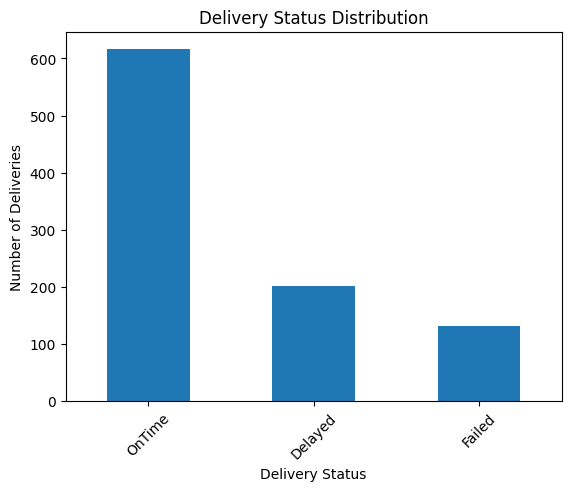

In [7]:
#delivery status
delivery_status_count = master["delivery_status"].value_counts()
delivery_status_count
delivery_status_count.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.show()

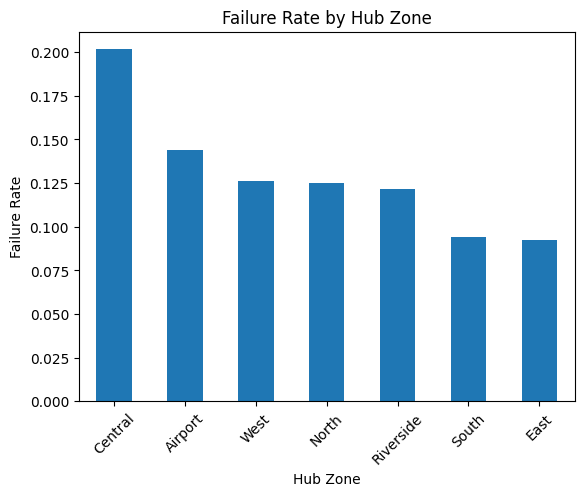

In [8]:
#failed deliveries by zone
zone_failure = master.groupby("zone")["failed_flag"].mean().sort_values(ascending=False)
zone_failure
zone_failure.plot(kind="bar")
plt.title("Failure Rate by Hub Zone")
plt.xlabel("Hub Zone")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.show()

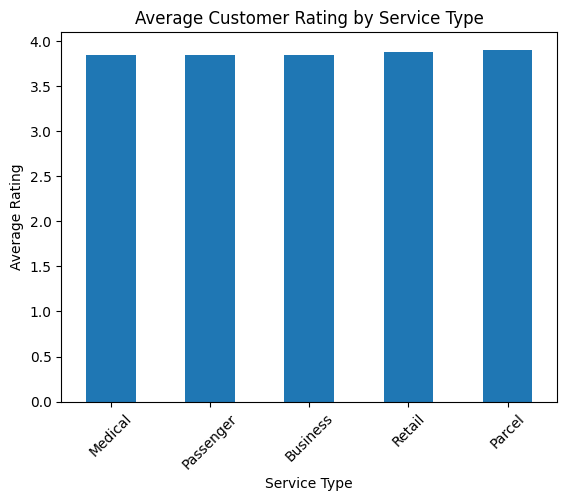

In [9]:
#average rating by service type
rating_service = master.groupby("service_type")["customer_rating_post_delivery"].mean().sort_values()
rating_service
rating_service.plot(kind="bar")
plt.title("Average Customer Rating by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

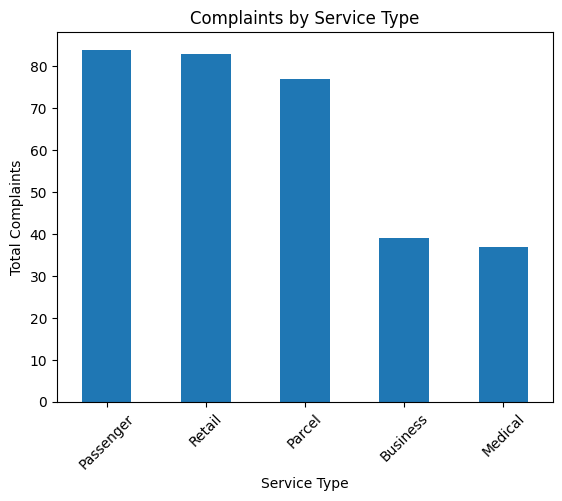

In [10]:
#complaints by service type
complaints_service = master.groupby("service_type")["complaint_count"].sum().sort_values(ascending=False)
complaints_service
complaints_service.plot(kind="bar")
plt.title("Complaints by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Complaints")
plt.xticks(rotation=45)
plt.show()

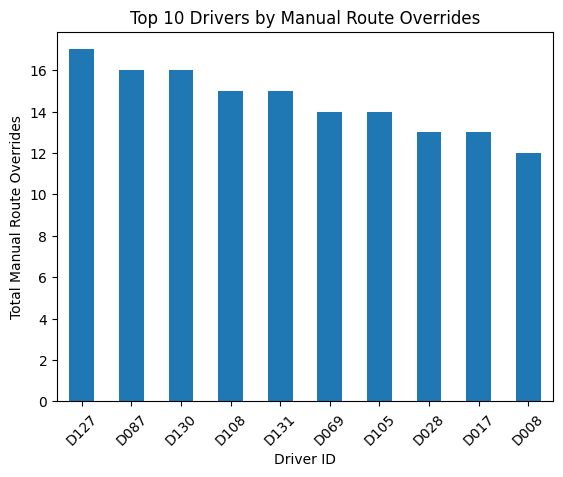

In [11]:
#driver route overrides
driver_overrides = master.groupby("driver_id").agg(
    total_deliveries=("delivery_id", "count"),
    total_overrides=("manual_route_override_count", "sum"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    failure_rate=("failed_flag", "mean")
).sort_values("total_overrides", ascending=False).head(10)

driver_overrides
driver_overrides["total_overrides"].plot(kind="bar")
plt.title("Top 10 Drivers by Manual Route Overrides")
plt.xlabel("Driver ID")
plt.ylabel("Total Manual Route Overrides")
plt.xticks(rotation=45)
plt.show()

In [12]:
#vehicle incident risk
vehicle_risk = master.groupby("vehicle_id").agg(
    vehicle_type=("vehicle_type", "first"),
    maintenance_status=("maintenance_status", "first"),
    battery_health_pct=("battery_health_pct", "first"),
    odometer_km=("odometer_km", "first"),
    incident_count=("incident_count", "sum"),
    failure_rate=("failed_flag", "mean")
).sort_values("incident_count", ascending=False).head(10)

vehicle_risk

,vehicle_type,maintenance_status,battery_health_pct,odometer_km,incident_count,failure_rate
vehicle_id,,,,,,
V047,EV,Scheduled,93.7,134347.0,9.0,0.000000
V108,Diesel,InRepair,54.6,141290.0,7.0,0.333333
V046,EV,Active,95.8,101425.0,6.0,0.100000
V030,CargoVan,Active,78.0,134360.0,6.0,0.133333
V097,EV,Active,92.1,18680.0,6.0,0.125000
V009,CargoVan,Active,68.8,156687.0,5.0,0.000000
V035,CargoVan,Active,83.6,73804.0,5.0,0.222222
V005,CargoVan,Active,58.6,146638.0,5.0,0.153846
V076,Diesel,InRepair,65.8,106063.0,5.0,0.166667


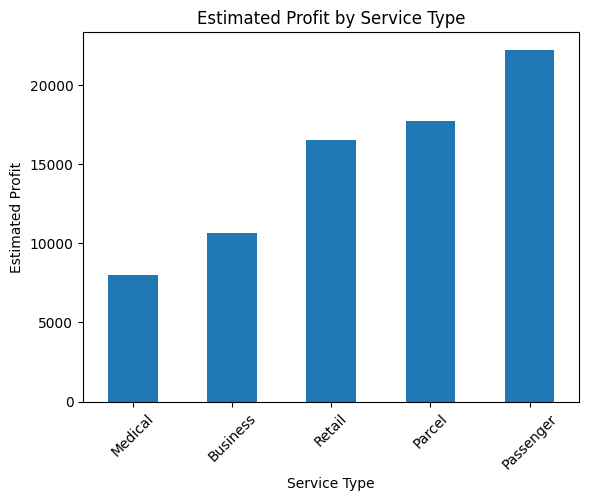

In [13]:
#profit by service type
profit_service = master.groupby("service_type")["profit_estimate"].sum().sort_values()
profit_service
profit_service.plot(kind="bar")
plt.title("Estimated Profit by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Estimated Profit")
plt.xticks(rotation=45)
plt.show()

In [14]:
#Save cleaned master file
master.to_csv("northstar_master_cleaned.csv", index=False)
from google.colab import files
files.download("northstar_master_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
#What is the size of each dataset?
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

orders (1250, 11)
deliveries (950, 13)
customers (650, 9)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
complaints (320, 10)
incidents (280, 7)
app_events (640, 10)


In [16]:
#What are the column names in each dataset?
for name, df in datasets.items():
    print("\n", name)
    print(df.columns.tolist())


 orders
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

 deliveries
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

 customers
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

 drivers
['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

 vehicles
['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version']

 hubs
['hub_id', 'hub_name', 'zone', 'hub_type', '

In [17]:
#Are there duplicate records?
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

orders duplicates: 0
deliveries duplicates: 0
customers duplicates: 0
drivers duplicates: 0
vehicles duplicates: 0
hubs duplicates: 0
complaints duplicates: 0
incidents duplicates: 0
app_events duplicates: 0


In [18]:
#What data types are used?
for name, df in datasets.items():
    print("\n", name)
    print(df.dtypes)


 orders
order_id                         object
customer_id                      object
service_type                     object
order_created_at         datetime64[ns]
promised_window_hours             int64
pickup_zone                      object
dropoff_zone                     object
priority_level                   object
order_value                     float64
booking_channel                  object
special_handling_flag             int64
dtype: object

 deliveries
delivery_id                              object
order_id                                 object
driver_id                                object
vehicle_id                               object
hub_id                                   object
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                          object
route_distance_km                       float64
manual_route_override_count               int64
proof_of_completion_missing               in

In [19]:
#What missing values exist?
for name, df in datasets.items():
    print("\nMissing values in", name)
    print(df.isnull().sum())


Missing values in orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Missing values in deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Missing values in customers
customer_id              0
age                      0
home_zone                0
customer_type            0
signu

In [20]:
#More data cleaning commands
orders = orders.drop_duplicates()
deliveries = deliveries.drop_duplicates()
customers = customers.drop_duplicates()
drivers = drivers.drop_duplicates()
vehicles = vehicles.drop_duplicates()
hubs = hubs.drop_duplicates()
complaints = complaints.drop_duplicates()
incidents = incidents.drop_duplicates()
app_events = app_events.drop_duplicates()

In [21]:
#Standardise text columns
orders["pickup_zone"] = orders["pickup_zone"].str.strip().str.title()
orders["dropoff_zone"] = orders["dropoff_zone"].str.strip().str.title()
customers["home_zone"] = customers["home_zone"].str.strip().str.title()
drivers["base_zone"] = drivers["base_zone"].str.strip().str.title()
vehicles["assigned_zone"] = vehicles["assigned_zone"].str.strip().str.title()
hubs["zone"] = hubs["zone"].str.strip().str.title()

In [22]:
#Convert date columns
orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce")
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")

In [23]:
#How can separate NorthStar files be joined?
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    high_incident_count=("severity", lambda x: (x == "High").sum()),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

app_summary = app_events.groupby("order_id").agg(
    app_event_count=("event_id", "count"),
    avg_api_latency_ms=("api_latency_ms", "mean"),
    app_success_rate=("success_flag", "mean")
).reset_index()

In [24]:
master = orders.merge(deliveries, on="order_id", how="left")
master = master.merge(customers, on="customer_id", how="left")
master = master.merge(hubs, on="hub_id", how="left")
master = master.merge(drivers, on="driver_id", how="left")
master = master.merge(vehicles, on="vehicle_id", how="left")
master = master.merge(complaint_summary, on="order_id", how="left")
master = master.merge(incident_summary, on="delivery_id", how="left")
master = master.merge(app_summary, on="order_id", how="left")

master.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,telematics_version,complaint_count,total_compensation,avg_resolution_days,incident_count,high_incident_count,avg_resolved_hours,app_event_count,avg_api_latency_ms,app_success_rate
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,v2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,204.0,1.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,244.0,1.0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,v2.0,1.0,8.66,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,v2.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,v2.1,1.0,54.41,8.0,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
#Fill missing value
master[[
    "complaint_count",
    "total_compensation",
    "incident_count",
    "high_incident_count",
    "app_event_count"
]] = master[[
    "complaint_count",
    "total_compensation",
    "incident_count",
    "high_incident_count",
    "app_event_count"
]].fillna(0)

In [26]:
#How long did each delivery take?
master["delivery_duration_hours"] = (
    master["delivery_completed_at"] - master["dispatch_time"]
).dt.total_seconds() / 3600

master[["delivery_id", "dispatch_time", "delivery_completed_at", "delivery_duration_hours"]].head()

,delivery_id,dispatch_time,delivery_completed_at,delivery_duration_hours
0,DL00937,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,2.398937
1,NaN,NaT,NaT,NaN
2,DL00925,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,8.861012
3,DL00002,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,-1.100000
4,DL00671,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,11.700013


In [27]:
#Which deliveries were late?
master["late_flag"] = np.where(
    master["delivery_duration_hours"] > master["promised_window_hours"],
    1,
    0
)

master[["delivery_id", "delivery_duration_hours", "promised_window_hours", "late_flag"]].head()

,delivery_id,delivery_duration_hours,promised_window_hours,late_flag
0,DL00937,2.398937,6,0
1,NaN,NaN,24,0
2,DL00925,8.861012,4,1
3,DL00002,-1.100000,2,0
4,DL00671,11.700013,12,0


In [28]:
#Which deliveries failed?
master["failed_flag"] = np.where(master["delivery_status"] == "Failed", 1, 0)

master[["delivery_id", "delivery_status", "failed_flag"]].head()

,delivery_id,delivery_status,failed_flag
0,DL00937,OnTime,0
1,NaN,NaN,0
2,DL00925,Delayed,0
3,DL00002,OnTime,0
4,DL00671,OnTime,0


In [29]:
#What is the estimated profit?
master["estimated_profit"] = master["order_value"] - master["fuel_or_charge_cost"]

master[["order_id", "order_value", "fuel_or_charge_cost", "estimated_profit"]].head()

,order_id,order_value,fuel_or_charge_cost,estimated_profit
0,O00001,126.65,15.82,110.83
1,O00002,109.30,NaN,NaN
2,O00003,33.50,13.16,20.34
3,O00004,10.04,13.41,-3.37
4,O00005,125.58,13.53,112.05


In [30]:
#Which deliveries have low customer ratings?
master["low_rating_flag"] = np.where(
    master["customer_rating_post_delivery"] < 3,
    1,
    0
)

master[["delivery_id", "customer_rating_post_delivery", "low_rating_flag"]].head()

,delivery_id,customer_rating_post_delivery,low_rating_flag
0,DL00937,4.29,0
1,NaN,NaN,0
2,DL00925,3.70,0
3,DL00002,5.00,0
4,DL00671,4.38,0


In [31]:
#Which cases are high-risk?
master["high_risk_case"] = np.where(
    (master["failed_flag"] == 1) |
    (master["complaint_count"] > 0) |
    (master["low_rating_flag"] == 1) |
    (master["high_incident_count"] > 0),
    1,
    0
)

master[["order_id", "failed_flag", "complaint_count", "low_rating_flag", "high_incident_count", "high_risk_case"]].head()

,order_id,failed_flag,complaint_count,low_rating_flag,high_incident_count,high_risk_case
0,O00001,0,0.0,0,0.0,0
1,O00002,0,0.0,0,0.0,0
2,O00003,0,1.0,0,0.0,1
3,O00004,0,0.0,0,0.0,0
4,O00005,0,1.0,0,0.0,1


In [32]:
#Which service type has the highest failure rate?
service_failure = master.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    failed_orders=("failed_flag", "sum"),
    failure_rate=("failed_flag", "mean")
).sort_values("failure_rate", ascending=False)

service_failure

,total_orders,failed_orders,failure_rate
service_type,,,
Business,165,25,0.151515
Medical,139,16,0.115108
Passenger,341,38,0.111437
Retail,297,28,0.094276
Parcel,308,25,0.081169


In [33]:
#Which zones have the highest late delivery rate?
zone_late = master.groupby("zone").agg(
    total_deliveries=("delivery_id", "count"),
    late_deliveries=("late_flag", "sum"),
    late_rate=("late_flag", "mean")
).sort_values("late_rate", ascending=False)

zone_late

,total_deliveries,late_deliveries,late_rate
zone,,,
Airport,104,59,0.567308
Central,243,119,0.489712
West,127,60,0.472441
North,136,58,0.426471
South,106,44,0.415094
East,119,49,0.411765
Riverside,115,46,0.400000


In [34]:
#Which hubs have the lowest customer rating?
hub_rating = master.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    failed_deliveries=("failed_flag", "sum")
).sort_values("avg_rating")

hub_rating.head(10)

,,,total_deliveries,avg_rating,failed_deliveries
hub_id,hub_name,zone,,,
H05,Central Core,Central,115,3.669558,23
H01,North Exchange,North,136,3.840593,17
H07,Riverside Hub,Riverside,115,3.881858,14
H06,Airport Hub,Airport,104,3.882136,15
H08,Midtown Relay,Central,128,3.884560,26
H03,East Dock,East,119,3.895862,11
H04,West Gate,West,127,3.915476,16
H02,South Link,South,106,3.950952,10


In [35]:
#Which drivers have the highest route override count?
driver_override = master.groupby(["driver_id", "base_zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    total_overrides=("manual_route_override_count", "sum"),
    avg_overrides=("manual_route_override_count", "mean"),
    failure_rate=("failed_flag", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean")
).sort_values("total_overrides", ascending=False)

driver_override.head(10)

,,total_deliveries,total_overrides,avg_overrides,failure_rate,avg_rating
driver_id,base_zone,,,,,
D127,Central,6,17.0,2.833333,0.000000,4.105000
D087,North,12,16.0,1.333333,0.166667,3.825000
D130,West,8,16.0,2.000000,0.125000,3.798571
D108,South,11,15.0,1.363636,0.272727,4.411818
D131,South,9,15.0,1.666667,0.333333,3.655556
D069,North,7,14.0,2.000000,0.142857,3.938571
D105,Riverside,7,14.0,2.000000,0.142857,4.205714
D028,North,7,13.0,1.857143,0.142857,3.537143
D017,East,10,13.0,1.300000,0.200000,3.679000


In [36]:
#Which vehicles are linked to most incidents?
vehicle_incidents = master.groupby(["vehicle_id", "vehicle_type", "maintenance_status"]).agg(
    total_deliveries=("delivery_id", "count"),
    total_incidents=("incident_count", "sum"),
    high_incidents=("high_incident_count", "sum"),
    failure_rate=("failed_flag", "mean")
).sort_values("total_incidents", ascending=False)

vehicle_incidents.head(10)

,,,total_deliveries,total_incidents,high_incidents,failure_rate
vehicle_id,vehicle_type,maintenance_status,,,,
V047,EV,Scheduled,17,9.0,4.0,0.000000
V108,Diesel,InRepair,9,7.0,1.0,0.333333
V046,EV,Active,10,6.0,3.0,0.100000
V030,CargoVan,Active,15,6.0,4.0,0.133333
V097,EV,Active,8,6.0,1.0,0.125000
V009,CargoVan,Active,9,5.0,0.0,0.000000
V035,CargoVan,Active,9,5.0,1.0,0.222222
V005,CargoVan,Active,13,5.0,1.0,0.153846
V076,Diesel,InRepair,6,5.0,0.0,0.166667


In [37]:
#Which complaint type costs the most?
complaint_cost = complaints.groupby("complaint_type").agg(
    total_complaints=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_compensation=("compensation_amount", "mean"),
    avg_resolution_days=("resolution_days", "mean")
).sort_values("total_compensation", ascending=False)

complaint_cost

,total_complaints,total_compensation,avg_compensation,avg_resolution_days
complaint_type,,,,
Delay,101,1696.84,18.051489,7.257426
MissedPickup,64,1423.40,22.593651,7.640625
AppIssue,53,980.72,19.614400,8.603774
DriverBehaviour,51,973.06,21.153478,8.156863
Billing,16,381.94,23.871250,7.750000
Damage,15,359.73,23.982000,11.333333
SupportExperience,20,342.50,17.125000,7.450000


In [38]:
#Which booking channel generates the highest revenue?
booking_revenue = orders.groupby("booking_channel").agg(
    total_orders=("order_id", "count"),
    total_revenue=("order_value", "sum"),
    avg_order_value=("order_value", "mean")
).sort_values("total_revenue", ascending=False)

booking_revenue

,total_orders,total_revenue,avg_order_value
booking_channel,,,
App,635,58172.54,91.610299
Web,269,25270.79,93.943457
Phone,257,22619.09,88.012023
API,64,5529.19,86.393594


In [39]:
#Which customer type complains the most?
customer_complaints = complaints.merge(customers, on="customer_id", how="left")

customer_type_complaints = customer_complaints.groupby("customer_type").agg(
    total_complaints=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).sort_values("total_complaints", ascending=False)

customer_type_complaints

,total_complaints,total_compensation,avg_resolution_days
customer_type,,,
Consumer,242,4764.11,7.855372
SME,50,868.15,8.020000
Enterprise,28,525.93,8.392857


In [40]:
#Which service type has highest estimated profit?
profit_service = master.groupby("service_type").agg(
    total_revenue=("order_value", "sum"),
    total_delivery_cost=("fuel_or_charge_cost", "sum"),
    total_profit=("estimated_profit", "sum"),
    avg_profit=("estimated_profit", "mean")
).sort_values("total_profit", ascending=False)

profit_service

,total_revenue,total_delivery_cost,total_profit,avg_profit
service_type,,,,
Passenger,32761.11,3248.56,22214.80,84.789313
Parcel,26985.62,3009.01,17726.43,77.071435
Retail,26734.06,2906.27,16538.59,73.832991
Business,15220.43,1655.91,10623.32,84.312063
Medical,12111.93,1379.48,7965.40,73.753704


In [41]:
#Which orders are loss-making?
loss_making_orders = master[master["estimated_profit"] < 0][[
    "order_id",
    "service_type",
    "order_value",
    "fuel_or_charge_cost",
    "estimated_profit",
    "delivery_status",
    "customer_rating_post_delivery"
]]

loss_making_orders.head(10)

,order_id,service_type,order_value,fuel_or_charge_cost,estimated_profit,delivery_status,customer_rating_post_delivery
3,O00004,Parcel,10.04,13.41,-3.37,OnTime,5.00
104,O00105,Passenger,18.19,20.02,-1.83,OnTime,5.00
108,O00109,Medical,9.68,12.84,-3.16,OnTime,3.13
138,O00139,Retail,4.22,10.97,-6.75,Delayed,3.94
175,O00176,Retail,14.76,16.90,-2.14,OnTime,3.65
312,O00313,Medical,11.11,13.62,-2.51,Delayed,4.18
511,O00512,Parcel,10.74,13.25,-2.51,Delayed,5.00
576,O00577,Parcel,16.62,18.94,-2.32,OnTime,4.18
643,O00644,Business,6.28,15.70,-9.42,Delayed,3.28
650,O00651,Parcel,7.14,11.92,-4.78,OnTime,4.71


In [42]:
#Which app events have highest failure rate?
app_event_failure = app_events.groupby("event_type").agg(
    total_events=("event_id", "count"),
    success_rate=("success_flag", "mean"),
    avg_latency=("api_latency_ms", "mean")
)

app_event_failure["failure_rate"] = 1 - app_event_failure["success_rate"]

app_event_failure.sort_values("failure_rate", ascending=False)

,total_events,success_rate,avg_latency,failure_rate
event_type,,,,
chat_escalated,38,0.500000,478.131579,0.500000
payment_retry,69,0.724638,472.681159,0.275362
chat_opened,88,1.000000,478.329545,0.000000
cancel_attempt,28,1.000000,417.142857,0.000000
delivery_instruction_update,75,1.000000,496.293333,0.000000
eta_refresh,105,1.000000,452.152381,0.000000
search_route,99,1.000000,456.505051,0.000000
track_order,138,1.000000,460.710145,0.000000


In [43]:
#Which app events have highest API latency?
app_latency = app_events.groupby("event_type").agg(
    total_events=("event_id", "count"),
    avg_api_latency=("api_latency_ms", "mean"),
    max_api_latency=("api_latency_ms", "max")
).sort_values("avg_api_latency", ascending=False)

app_latency

,total_events,avg_api_latency,max_api_latency
event_type,,,
delivery_instruction_update,75,496.293333,1285
chat_opened,88,478.329545,1690
chat_escalated,38,478.131579,1402
payment_retry,69,472.681159,1701
track_order,138,460.710145,1660
search_route,99,456.505051,1265
eta_refresh,105,452.152381,1285
cancel_attempt,28,417.142857,1039


In [44]:
#Are manual route overrides linked to lower ratings?
override_rating = master.groupby("manual_route_override_count").agg(
    total_deliveries=("delivery_id", "count"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    failure_rate=("failed_flag", "mean")
).sort_values("manual_route_override_count")

override_rating

,total_deliveries,avg_rating,failure_rate
manual_route_override_count,,,
0.0,399,3.900816,0.115288
1.0,310,3.884463,0.164516
2.0,153,3.824600,0.143791
3.0,57,3.668393,0.175439
4.0,23,3.865652,0.130435
5.0,7,3.378571,0.000000
7.0,1,4.010000,0.000000


In [45]:
#Do lower battery vehicles fail more often?
battery_failure = master.groupby("vehicle_type").agg(
    avg_battery_health=("battery_health_pct", "mean"),
    failure_rate=("failed_flag", "mean"),
    avg_odometer=("odometer_km", "mean"),
    total_incidents=("incident_count", "sum")
).sort_values("failure_rate", ascending=False)

battery_failure

,avg_battery_health,failure_rate,avg_odometer,total_incidents
vehicle_type,,,,
Diesel,71.209722,0.180556,87566.090278,47.0
CargoVan,72.079372,0.170404,109566.354260,67.0
Hybrid,77.985778,0.155738,122620.872951,66.0
EV,82.046547,0.088496,127379.165192,100.0


In [46]:
#Which zones are most problematic overall?
zone_risk = master.groupby("zone").agg(
    total_deliveries=("delivery_id", "count"),
    failure_rate=("failed_flag", "mean"),
    late_rate=("late_flag", "mean"),
    avg_rating=("customer_rating_post_delivery", "mean"),
    total_complaints=("complaint_count", "sum"),
    total_incidents=("incident_count", "sum"),
    total_compensation=("total_compensation", "sum")
).sort_values(["failure_rate", "total_complaints"], ascending=False)

zone_risk

,total_deliveries,failure_rate,late_rate,avg_rating,total_complaints,total_incidents,total_compensation
zone,,,,,,,
Central,243,0.201646,0.489712,3.782479,65.0,77.0,1435.93
Airport,104,0.144231,0.567308,3.882136,23.0,32.0,447.77
West,127,0.125984,0.472441,3.915476,28.0,34.0,560.26
North,136,0.125000,0.426471,3.840593,32.0,31.0,538.79
Riverside,115,0.121739,0.400000,3.881858,33.0,35.0,669.51
South,106,0.094340,0.415094,3.950952,18.0,33.0,232.77
East,119,0.092437,0.411765,3.895862,33.0,38.0,557.31


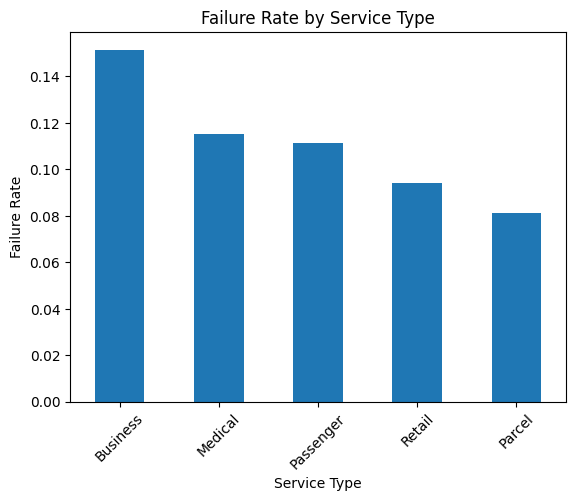

In [47]:
#Failure rate by service type
service_failure["failure_rate"].plot(kind="bar")

plt.title("Failure Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.show()

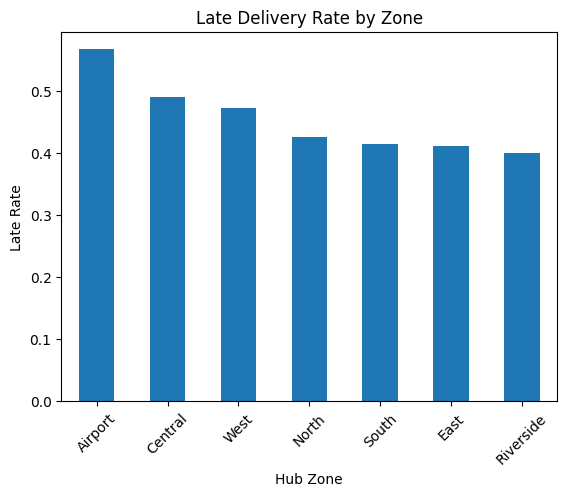

In [48]:
#Late delivery rate by zone
zone_late["late_rate"].plot(kind="bar")

plt.title("Late Delivery Rate by Zone")
plt.xlabel("Hub Zone")
plt.ylabel("Late Rate")
plt.xticks(rotation=45)
plt.show()

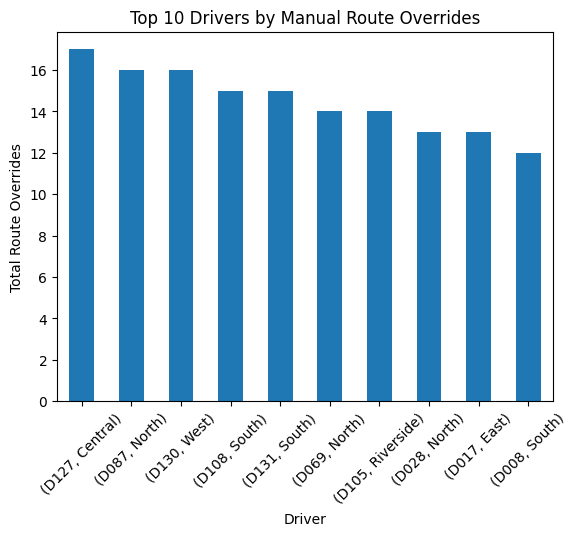

In [49]:
#Top 10 drivers by route overrides
driver_override["total_overrides"].head(10).plot(kind="bar")

plt.title("Top 10 Drivers by Manual Route Overrides")
plt.xlabel("Driver")
plt.ylabel("Total Route Overrides")
plt.xticks(rotation=45)
plt.show()

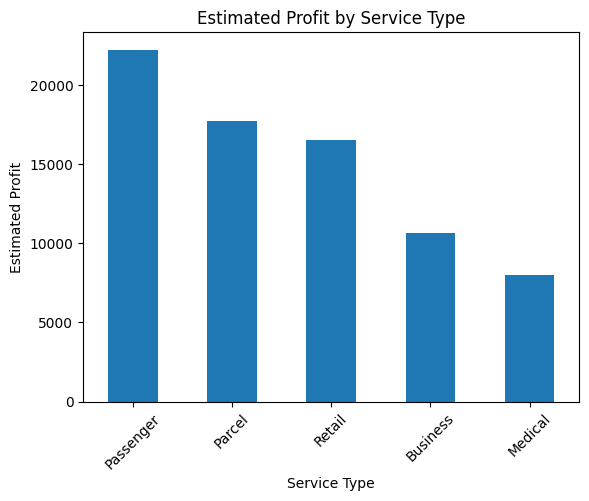

In [50]:
#Estimated profit by service type
profit_service["total_profit"].plot(kind="bar")

plt.title("Estimated Profit by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Estimated Profit")
plt.xticks(rotation=45)
plt.show()

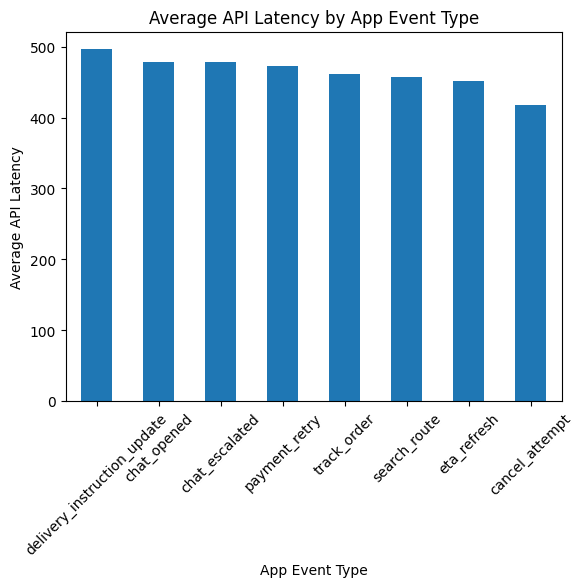

In [51]:
#API latency by app event type
app_latency["avg_api_latency"].plot(kind="bar")

plt.title("Average API Latency by App Event Type")
plt.xlabel("App Event Type")
plt.ylabel("Average API Latency")
plt.xticks(rotation=45)
plt.show()

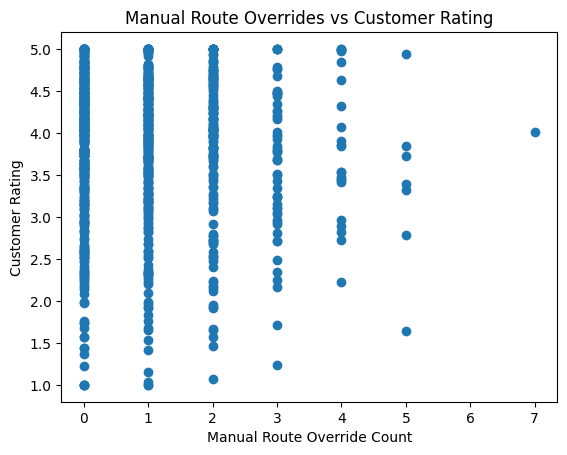

In [52]:
#Scatterplot — route overrides vs customer rating
plt.scatter(
    master["manual_route_override_count"],
    master["customer_rating_post_delivery"]
)

plt.title("Manual Route Overrides vs Customer Rating")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Customer Rating")
plt.show()

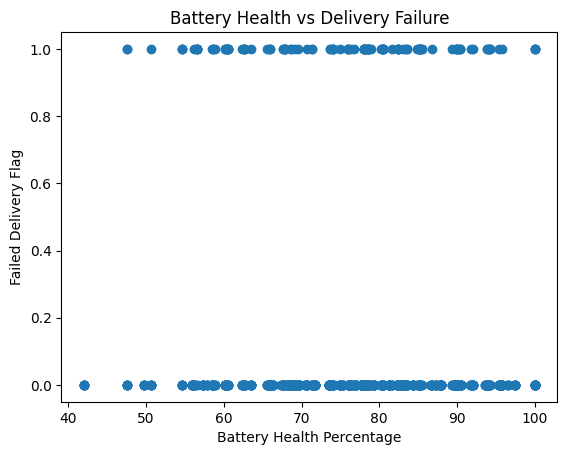

In [53]:
#Scatterplot — battery health vs failure flag
plt.scatter(
    master["battery_health_pct"],
    master["failed_flag"]
)

plt.title("Battery Health vs Delivery Failure")
plt.xlabel("Battery Health Percentage")
plt.ylabel("Failed Delivery Flag")
plt.show()

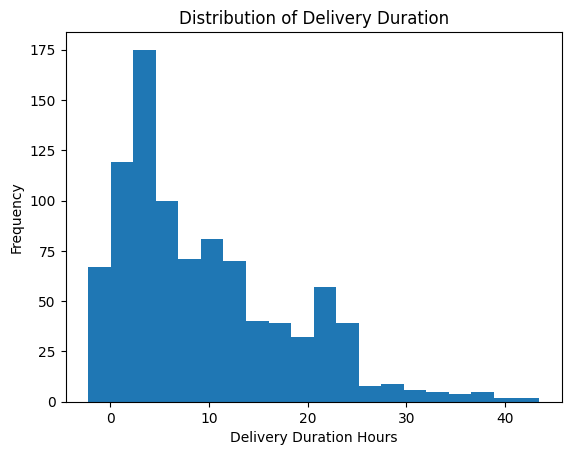

In [54]:
#Histogram — delivery duration
master["delivery_duration_hours"].dropna().plot(kind="hist", bins=20)

plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Duration Hours")
plt.ylabel("Frequency")
plt.show()

In [55]:
#Calculate average, minimum and maximum delivery duration using NumPy
duration_values = master["delivery_duration_hours"].dropna().values

print("Mean duration:", np.mean(duration_values))
print("Minimum duration:", np.min(duration_values))
print("Maximum duration:", np.max(duration_values))
print("Standard deviation:", np.std(duration_values))

Mean duration: 9.545486064205754
Minimum duration: -2.2144772013888887
Maximum duration: 43.456918198055554
Standard deviation: 8.643975592555892


In [56]:
#Find high-cost deliveries using NumPy percentile
cost_threshold = np.percentile(master["fuel_or_charge_cost"].dropna(), 75)

high_cost_deliveries = master[master["fuel_or_charge_cost"] >= cost_threshold]

high_cost_deliveries[[
    "order_id",
    "service_type",
    "fuel_or_charge_cost",
    "delivery_status",
    "customer_rating_post_delivery"
]].head(10)

,order_id,service_type,fuel_or_charge_cost,delivery_status,customer_rating_post_delivery
0,O00001,Passenger,15.82,OnTime,4.29
12,O00013,Retail,17.02,OnTime,3.74
16,O00017,Parcel,19.77,OnTime,4.94
18,O00019,Passenger,16.91,OnTime,3.52
32,O00033,Retail,16.80,Failed,3.20
42,O00043,Retail,15.76,OnTime,4.81
46,O00047,Medical,16.28,OnTime,4.70
51,O00052,Retail,16.00,Delayed,3.72
54,O00055,Retail,21.88,Delayed,3.55
60,O00061,Passenger,18.46,OnTime,4.46


In [57]:
#Create performance score using NumPy
master["performance_score"] = np.where(
    master["failed_flag"] == 1,
    0,
    100
)

master["performance_score"] = master["performance_score"] - (
    master["late_flag"] * 20
) - (
    master["low_rating_flag"] * 20
) - (
    master["complaint_count"] * 10
)

master["performance_score"] = master["performance_score"].clip(lower=0, upper=100)

master[[
    "order_id",
    "failed_flag",
    "late_flag",
    "low_rating_flag",
    "complaint_count",
    "performance_score"
]].head()

,order_id,failed_flag,late_flag,low_rating_flag,complaint_count,performance_score
0,O00001,0,0,0,0.0,100.0
1,O00002,0,0,0,0.0,100.0
2,O00003,0,1,0,1.0,70.0
3,O00004,0,0,0,0.0,100.0
4,O00005,0,0,0,1.0,90.0
